## Imports

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv("hw1_dataset.csv")
df

,experimental_proprty,MS_enc,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,...,AATS0Z,ATSC0are,ATSC2pe,SsCl,ATS6v,AATSC1dv,nFARing,AATS2v,Xp-7dv,n6Ring
0,3.54,PPENPINEAPLE42,5,1,0,83,7305.483137,1,2.105782,1,...,26.444444,2.995920,-0.508149,5.976320,16177.071020,1.102539,0,223.767000,0.903808,3
1,-1.18,PPENPINEAPLE42,11,0,3,114,9532.633527,0,4.605907,0,...,31.796610,9.996180,2.554415,0.000000,29893.511410,0.854039,1,225.916087,1.887922,3
2,3.69,PPENPINEAPLE42,5,1,2,69,5845.023999,0,1.422763,1,...,35.513514,3.773573,-0.113725,6.285975,17264.331087,0.793417,1,241.492298,1.098203,2
3,3.37,HTXPTDWTTWOBJR,9,1,3,105,7388.625069,0,0.000000,1,...,35.869565,6.699887,-0.114253,5.958016,20506.327989,0.421656,1,254.318903,1.164550,2
4,3.10,PPENPINEAPLE42,7,0,2,68,9082.560968,1,9.734779,0,...,21.018182,5.862455,1.664804,0.000000,22748.101433,1.602810,0,207.685522,0.492884,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2.06,PPENPINEAPLE42,12,2,5,111,11428.201740,0,0.000000,0,...,24.970588,12.971651,-0.366319,0.000000,24723.464405,1.033473,0,222.862881,0.893994,3
1996,3.03,PPENPINEAPLE42,6,2,2,66,7372.541891,0,0.000000,1,...,28.888889,7.099480,-0.890364,5.860789,14440.287915,0.773582,0,225.391710,0.728822,3
1997,3.80,VMZXVMIGMRZLPU,9,0,0,74,9326.669184,0,7.191590,0,...,22.285714,8.026598,1.374708,0.000000,19394.335824,1.780040,0,197.446318,0.562785,3
1998,3.22,HTXPTDWTTWOBJR,9,1,2,103,6732.866534,0,0.000000,1,...,38.000000,5.735850,1.192770,5.946582,17791.951828,0.622862,1,265.517011,1.081912,2


<Axes: xlabel='MS_enc'>

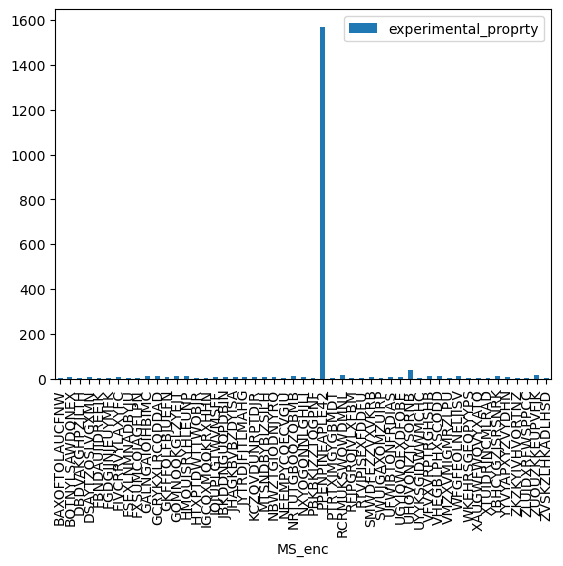

In [8]:
b = df.groupby("MS_enc").agg("count").reset_index()
b = b[["MS_enc", "experimental_proprty"]]
b.plot.bar(x = "MS_enc", y ="experimental_proprty")

## Pre-Processing

In [10]:
print(df.isna().sum())

experimental_proprty    0
MS_enc                  0
nHetero                 0
nX                      0
C2SP3                   0
                       ..
AATSC1dv                0
nFARing                 0
AATS2v                  0
Xp-7dv                  0
n6Ring                  0
Length: 552, dtype: int64


In [11]:
df.max()

experimental_proprty               4.5
MS_enc                  ZVSKZLHKADLHSD
nHetero                             34
nX                                   9
C2SP3                               27
                             ...      
AATSC1dv                       2.42383
nFARing                              2
AATS2v                       341.67624
Xp-7dv                        4.276742
n6Ring                               8
Length: 552, dtype: object

In [12]:
df.min()

experimental_proprty              -1.5
MS_enc                  BAXOFTOLAUCFNW
nHetero                              1
nX                                   0
C2SP3                                0
                             ...      
AATSC1dv                     -1.733701
nFARing                              0
AATS2v                      146.574278
Xp-7dv                             0.0
n6Ring                               0
Length: 552, dtype: object

In [13]:
df.replace(['Computation failed'], np.nan, inplace=True)

In [14]:
df.isna().sum()
df = df.dropna()
df

,experimental_proprty,MS_enc,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,...,AATS0Z,ATSC0are,ATSC2pe,SsCl,ATS6v,AATSC1dv,nFARing,AATS2v,Xp-7dv,n6Ring
1,-1.18,PPENPINEAPLE42,11,0,3,114,9532.633527,0,4.605907,0,...,31.796610,9.996180,2.554415,0.000000,29893.511410,0.854039,1,225.916087,1.887922,3
2,3.69,PPENPINEAPLE42,5,1,2,69,5845.023999,0,1.422763,1,...,35.513514,3.773573,-0.113725,6.285975,17264.331087,0.793417,1,241.492298,1.098203,2
3,3.37,HTXPTDWTTWOBJR,9,1,3,105,7388.625069,0,0.000000,1,...,35.869565,6.699887,-0.114253,5.958016,20506.327989,0.421656,1,254.318903,1.164550,2
4,3.10,PPENPINEAPLE42,7,0,2,68,9082.560968,1,9.734779,0,...,21.018182,5.862455,1.664804,0.000000,22748.101433,1.602810,0,207.685522,0.492884,1
5,3.14,PPENPINEAPLE42,2,0,2,81,6942.643519,0,0.000000,0,...,20.227273,2.706425,-0.378879,0.000000,13538.334382,0.698919,1,235.809257,0.779264,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2.06,PPENPINEAPLE42,12,2,5,111,11428.201740,0,0.000000,0,...,24.970588,12.971651,-0.366319,0.000000,24723.464405,1.033473,0,222.862881,0.893994,3
1996,3.03,PPENPINEAPLE42,6,2,2,66,7372.541891,0,0.000000,1,...,28.888889,7.099480,-0.890364,5.860789,14440.287915,0.773582,0,225.391710,0.728822,3
1997,3.80,VMZXVMIGMRZLPU,9,0,0,74,9326.669184,0,7.191590,0,...,22.285714,8.026598,1.374708,0.000000,19394.335824,1.780040,0,197.446318,0.562785,3
1998,3.22,HTXPTDWTTWOBJR,9,1,2,103,6732.866534,0,0.000000,1,...,38.000000,5.735850,1.192770,5.946582,17791.951828,0.622862,1,265.517011,1.081912,2


In [15]:
ndf = pd.get_dummies(df, columns=['MS_enc', 'SMIF'], drop_first = True)
ndf

,experimental_proprty,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,nFAHRing,...,MS_enc_XAUGWFWQVYXATQ,MS_enc_XTUIDRJNCMLRAD,MS_enc_YBHCYGZJSRSNRK,MS_enc_YYVYAPXYZVYDHN,MS_enc_ZKZKYIVHVORTNZ,MS_enc_ZLUIDXRFWSPPCC,MS_enc_ZUOUZKKEUPVFJK,MS_enc_ZVSKZLHKADLHSD,SMIF_bigger,SMIF_the_biggest
1,-1.18,11,0,3,114,9532.633527,0,4.605907,0,1,...,False,False,False,False,False,False,False,False,False,True
2,3.69,5,1,2,69,5845.023999,0,1.422763,1,1,...,False,False,False,False,False,False,False,False,False,False
3,3.37,9,1,3,105,7388.625069,0,0.000000,1,1,...,False,False,False,False,False,False,False,False,True,False
4,3.10,7,0,2,68,9082.560968,1,9.734779,0,0,...,False,False,False,False,False,False,False,False,True,False
5,3.14,2,0,2,81,6942.643519,0,0.000000,0,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2.06,12,2,5,111,11428.201740,0,0.000000,0,0,...,False,False,False,False,False,False,False,False,False,True
1996,3.03,6,2,2,66,7372.541891,0,0.000000,1,0,...,False,False,False,False,False,False,False,False,True,False
1997,3.80,9,0,0,74,9326.669184,0,7.191590,0,0,...,False,False,False,False,False,False,False,False,True,False
1998,3.22,9,1,2,103,6732.866534,0,0.000000,1,1,...,False,False,False,False,False,False,False,False,True,False


## Correlation Matrix

In [17]:
cor = ndf.corr()
cor

,experimental_proprty,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,nFAHRing,...,MS_enc_XAUGWFWQVYXATQ,MS_enc_XTUIDRJNCMLRAD,MS_enc_YBHCYGZJSRSNRK,MS_enc_YYVYAPXYZVYDHN,MS_enc_ZKZKYIVHVORTNZ,MS_enc_ZLUIDXRFWSPPCC,MS_enc_ZUOUZKKEUPVFJK,MS_enc_ZVSKZLHKADLHSD,SMIF_bigger,SMIF_the_biggest
experimental_proprty,1.000000,-0.007100,0.104173,-0.013645,0.219831,0.141030,0.015105,0.048404,0.038127,-0.066070,...,0.020242,0.066271,0.045118,0.018279,0.061671,-0.014874,-0.127905,-0.015137,0.072062,0.094612
nHetero,-0.007100,1.000000,0.472216,0.152705,0.550042,0.628380,0.249156,0.234468,0.201223,-0.033109,...,0.030432,-0.059326,0.011178,-0.076896,0.037768,0.063824,-0.003028,-0.063060,0.045466,0.573810
nX,0.104173,0.472216,1.000000,-0.012555,0.152509,0.144260,0.093243,-0.131407,0.458306,-0.072994,...,0.062773,-0.007980,0.008829,-0.048904,0.010973,0.094550,0.117867,-0.026934,0.009936,0.264579
C2SP3,-0.013645,0.152705,-0.012555,1.000000,0.326227,0.568558,-0.070581,0.084111,0.014115,0.136391,...,-0.036980,0.081044,0.144919,-0.027750,-0.012619,-0.022704,-0.067495,-0.046678,0.045126,0.272668
MPC5,0.219831,0.550042,0.152509,0.326227,1.000000,0.747003,0.361376,0.276409,0.072620,0.175168,...,-0.028842,0.012767,0.076478,-0.011651,-0.016227,-0.006156,-0.057782,-0.073894,0.086329,0.568977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MS_enc_ZLUIDXRFWSPPCC,-0.014874,0.063824,0.094550,-0.022704,-0.006156,0.020174,0.052978,0.015976,-0.023668,-0.018386,...,-0.002221,-0.002484,-0.003518,-0.003336,-0.002484,1.000000,-0.004014,-0.002484,0.018031,0.016145
MS_enc_ZUOUZKKEUPVFJK,-0.127905,-0.003028,0.117867,-0.067495,-0.057782,-0.060451,-0.044874,-0.030193,0.011713,-0.033229,...,-0.004014,-0.004489,-0.006357,-0.006029,-0.004489,-0.004014,1.000000,-0.004489,0.025572,-0.047002
MS_enc_ZVSKZLHKADLHSD,-0.015137,-0.063060,-0.026934,-0.046678,-0.073894,-0.065537,-0.027768,-0.037475,-0.008936,-0.020562,...,-0.002484,-0.002778,-0.003934,-0.003731,-0.002778,-0.002484,-0.004489,1.000000,-0.036266,-0.037656
SMIF_bigger,0.072062,0.045466,0.009936,0.045126,0.086329,0.013959,0.017460,0.017954,-0.029845,-0.005142,...,-0.007198,-0.013693,0.044540,-0.015023,0.076595,0.018031,0.025572,-0.036266,1.000000,-0.491617


In [18]:
s = cor.head(100)
s

,experimental_proprty,nHetero,nX,C2SP3,MPC5,ATS0i,NaasN,SsCH3,nCl,nFAHRing,...,MS_enc_XAUGWFWQVYXATQ,MS_enc_XTUIDRJNCMLRAD,MS_enc_YBHCYGZJSRSNRK,MS_enc_YYVYAPXYZVYDHN,MS_enc_ZKZKYIVHVORTNZ,MS_enc_ZLUIDXRFWSPPCC,MS_enc_ZUOUZKKEUPVFJK,MS_enc_ZVSKZLHKADLHSD,SMIF_bigger,SMIF_the_biggest
experimental_proprty,1.000000,-0.007100,0.104173,-0.013645,0.219831,0.141030,0.015105,0.048404,0.038127,-0.066070,...,0.020242,0.066271,0.045118,0.018279,0.061671,-0.014874,-0.127905,-0.015137,0.072062,0.094612
nHetero,-0.007100,1.000000,0.472216,0.152705,0.550042,0.628380,0.249156,0.234468,0.201223,-0.033109,...,0.030432,-0.059326,0.011178,-0.076896,0.037768,0.063824,-0.003028,-0.063060,0.045466,0.573810
nX,0.104173,0.472216,1.000000,-0.012555,0.152509,0.144260,0.093243,-0.131407,0.458306,-0.072994,...,0.062773,-0.007980,0.008829,-0.048904,0.010973,0.094550,0.117867,-0.026934,0.009936,0.264579
C2SP3,-0.013645,0.152705,-0.012555,1.000000,0.326227,0.568558,-0.070581,0.084111,0.014115,0.136391,...,-0.036980,0.081044,0.144919,-0.027750,-0.012619,-0.022704,-0.067495,-0.046678,0.045126,0.272668
MPC5,0.219831,0.550042,0.152509,0.326227,1.000000,0.747003,0.361376,0.276409,0.072620,0.175168,...,-0.028842,0.012767,0.076478,-0.011651,-0.016227,-0.006156,-0.057782,-0.073894,0.086329,0.568977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATSC1pe,0.248968,-0.188992,-0.257189,0.064307,0.078428,0.133567,0.155309,0.237062,-0.073077,0.039881,...,-0.010900,0.004903,0.000177,-0.020063,-0.082076,-0.049380,-0.064196,-0.042394,0.009922,0.059583
VSA_EState9,0.160951,-0.187165,-0.107410,-0.050469,0.049099,-0.003632,0.072172,0.215679,-0.066393,0.026897,...,-0.065955,0.012637,-0.023588,0.009947,-0.003795,-0.049842,-0.080291,-0.003795,0.010370,-0.075067
SdNH,-0.141789,-0.030585,-0.020527,-0.045000,-0.106302,-0.072220,-0.028829,-0.050032,0.024545,-0.004713,...,-0.004348,-0.004863,-0.006887,-0.006532,-0.004863,-0.004348,-0.007859,-0.004863,-0.039445,-0.054395
AATSC0Z,-0.009142,0.091571,0.204705,-0.066327,-0.098918,-0.121266,-0.034834,-0.089325,0.240629,-0.033932,...,0.036280,-0.008187,-0.020376,-0.031664,0.029407,-0.003352,0.009442,-0.014247,0.034729,0.023006


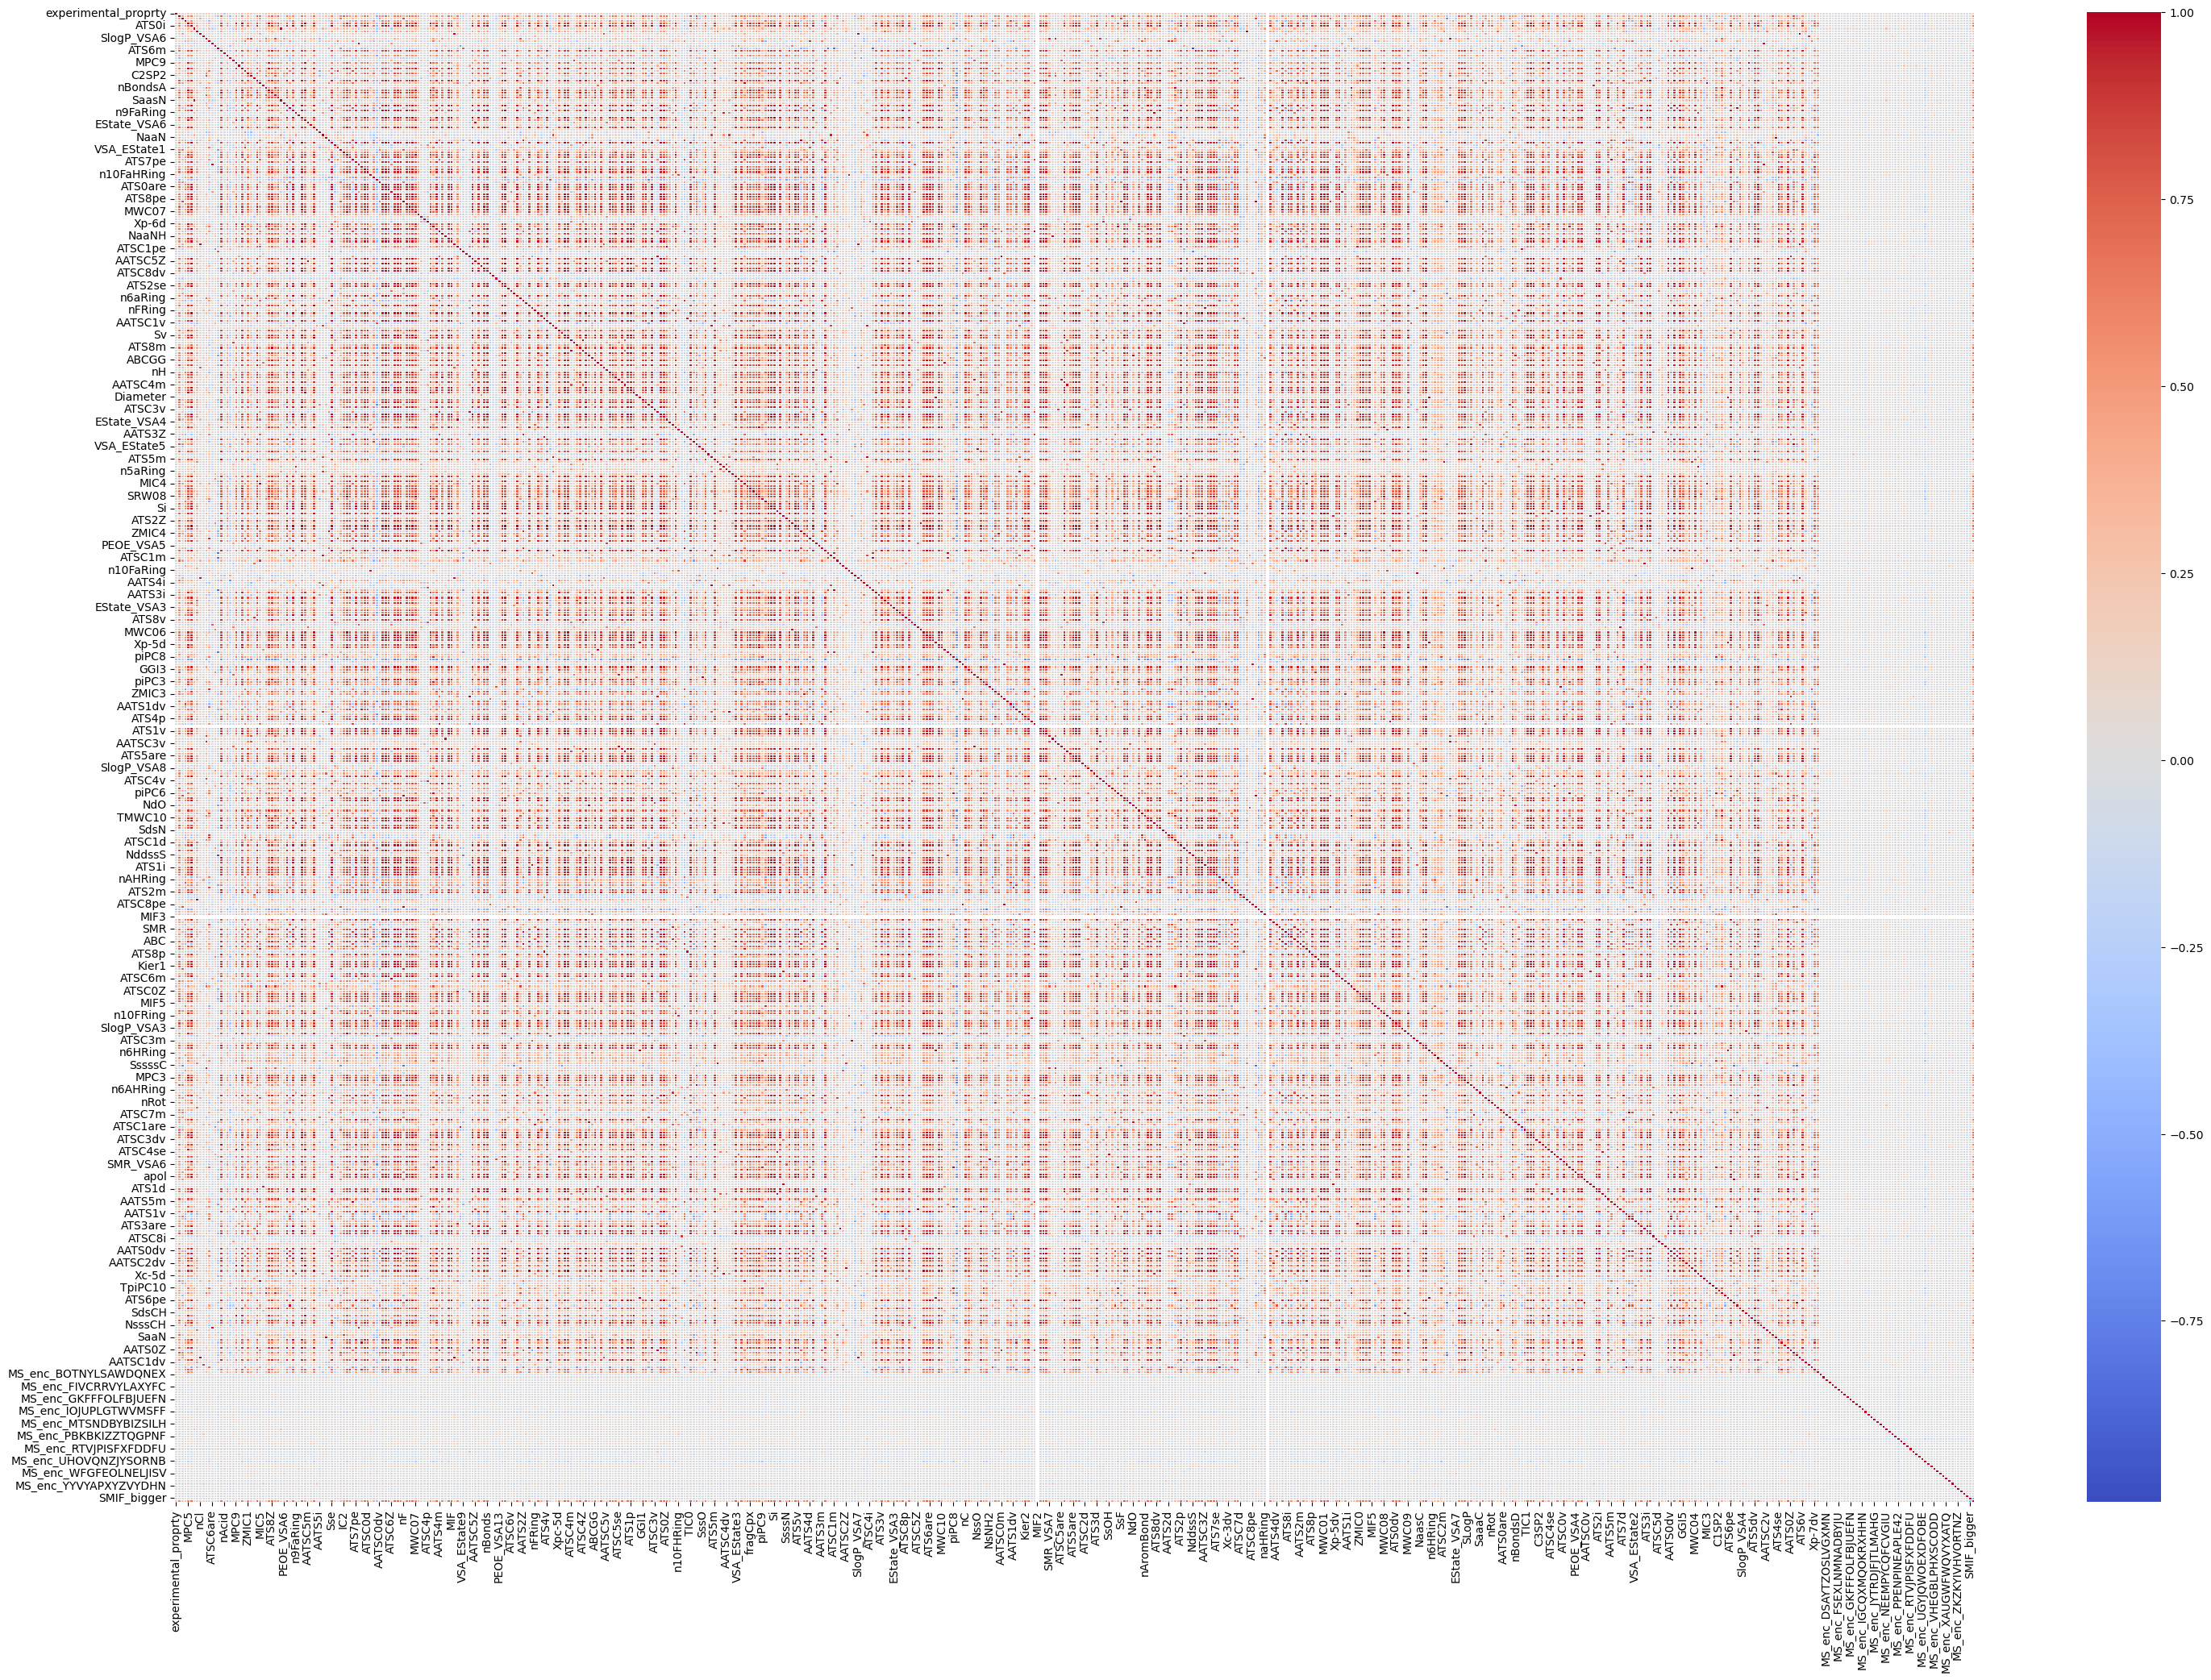

In [19]:
plt.figure(figsize=(36,24))
sns.heatmap(cor, cmap="coolwarm", annot=False, fmt=".2f", linewidths=.5, cbar=True)

plt.show()

In [20]:
cor_high = cor[((cor >= 0.5) | (cor <= -0.5)) & (cor != 1.000000)]
cor_high = cor_high.stack().reset_index()
cor_high.columns = ['var1', 'var2', 'Correlation']
cor_clean = cor_high[(cor_high['var1'] < cor_high['var2'])].reset_index(drop=True)
cor_clean = cor_clean.sort_values(by= 'Correlation', ascending = False)
cor_clean.head(50)

,var1,var2,Correlation
7475,Sp,apol,1.000000
10454,MIF6,MW2,1.000000
10514,MIF6,MW,1.000000
13942,ECIndex,Radius,1.000000
8838,Diameter,ECIndex,1.000000
8839,Diameter,Radius,1.000000
13943,ECIndex,WPath,1.000000
8840,Diameter,WPath,1.000000
23118,Radius,WPath,1.000000
16872,MW,Sm,0.999996


In [21]:
cor_low = cor[(cor <= 0.01) & (cor >= -0.01) & (cor != 1.0)]
cor_low = cor_low.stack().reset_index()
cor_low.columns = ['var1', 'var2', 'Correlation']
cor_clean = cor_low[cor_low['var1'] < cor_low['var2']].reset_index(drop=True)
cor_clean = cor_clean.sort_values(by= 'Correlation', ascending = False)
cor_clean.head(50)

,var1,var2,Correlation
11525,MS_enc_RFJPGRQJVLXFBM,PEOE_VSA11,0.009999
589,ATS0se,MS_enc_KCZQVDUNRPTDJR,0.009995
4778,AATSC0m,MS_enc_JHAGKBVBZDYISA,0.009994
2536,SlogP_VSA11,Xp-3dv,0.009991
11402,MS_enc_PPENPINEAPLE42,SdNH,0.009988
3806,ATSC3Z,n5AHRing,0.009985
3777,AATSC2Z,MS_enc_ZUOUZKKEUPVFJK,0.009974
285,SsBr,SsNH2,0.009970
8289,AATS5m,AATSC0v,0.009970
1283,ATSC3i,n9FaHRing,0.009965


In [22]:
target = cor.iloc[0]
target = target.sort_values(ascending = False)
target

experimental_proprty    1.000000
SLogP                   0.427319
nAromAtom               0.324931
nBondsA                 0.322809
nAromBond               0.322809
                          ...   
nAcid                  -0.314081
BalabanJ               -0.329882
FilterItLogS           -0.370540
MIF2                         NaN
MIF3                         NaN
Name: experimental_proprty, Length: 602, dtype: float64

## Outliers

In [24]:
df_sub = df.select_dtypes(include=['float64'])
outliers_dict = {}
for col in df_sub.columns:
    Q1 = df_sub[col].quantile(0.25)
    Q3 = df_sub[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_sub[(df_sub[col] < lower_bound) | (df_sub[col] > upper_bound)][col]
    if not outliers.empty:
        outliers_dict[col] = outliers.index.tolist()
outliers_dict

{'experimental_proprty': [160,
  712,
  875,
  1121,
  1299,
  1344,
  1367,
  1667,
  1701,
  1855],
 'ATS0i': [139, 212, 442, 684, 905, 1026, 1236, 1397, 1646, 1818],
 'SsCH3': [4,
  17,
  95,
  139,
  178,
  212,
  249,
  321,
  413,
  442,
  581,
  799,
  812,
  937,
  1089,
  1137,
  1176,
  1185,
  1260,
  1312,
  1317,
  1325,
  1397,
  1455,
  1501,
  1646,
  1704,
  1711,
  1717,
  1781,
  1818,
  1861,
  1895,
  1948,
  1964],
 'SlogP_VSA6': [27,
  190,
  384,
  497,
  822,
  894,
  905,
  1236,
  1250,
  1254,
  1301,
  1647],
 'AATS3d': [9,
  12,
  134,
  258,
  561,
  631,
  637,
  712,
  1117,
  1280,
  1509,
  1521,
  1701,
  1780,
  1851,
  1877,
  1889,
  1948],
 'ATSC6are': [8,
  37,
  47,
  72,
  79,
  80,
  86,
  97,
  111,
  113,
  124,
  129,
  140,
  152,
  174,
  181,
  182,
  185,
  197,
  206,
  260,
  290,
  293,
  299,
  328,
  337,
  356,
  363,
  381,
  408,
  412,
  417,
  426,
  451,
  452,
  491,
  492,
  509,
  538,
  564,
  586,
  595,
  596,
  644,
 

## PCA

In [26]:
y = ndf['experimental_proprty']
X = ndf.drop(columns ='experimental_proprty')

X = StandardScaler().fit_transform(X)
pca = PCA(n_components = 2)
p_c = pca.fit_transform(X)
e_v = pca.explained_variance_ratio_

p_c = pd.DataFrame(p_c, columns=['A', 'B'])
p_c['y'] = y
e_v

array([0.33344061, 0.08347055])

In [27]:
p_c

,A,B,y
0,13.812963,2.971409,NaN
1,-9.097076,-0.447081,-1.18
2,2.293632,6.627661,3.69
3,1.403974,-5.593897,3.37
4,-7.074484,-9.408722,3.10
...,...,...,...
1800,16.253910,2.231098,1.25
1801,-5.334168,-5.244921,3.92
1802,1.819364,-5.379188,1.26
1803,-0.169577,8.639630,-0.09


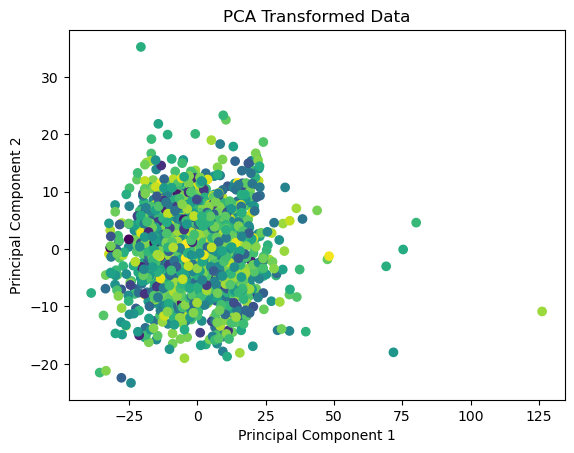

In [31]:
plt.scatter(p_c['A'], p_c['B'], c=p_c['y'], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Data')
plt.show()

## Bonus Q's:

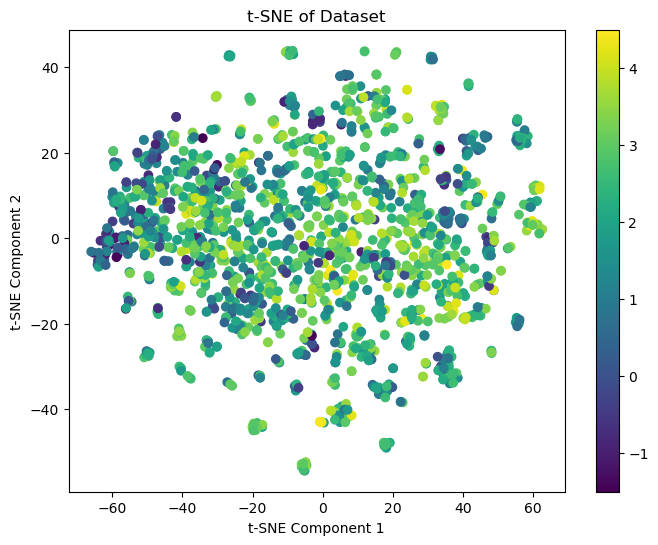

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

y = ndf['experimental_proprty']
X = ndf.drop(columns ='experimental_proprty')
X = StandardScaler().fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_t = tsne.fit_transform(X)

# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(X_t[:, 0], X_t[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.title('t-SNE of Dataset')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()
